# Exercise 3

## Task 1: The Laplace mechanism for counting query

The most basic tool in the DP toolkit is the **Laplace Mechanism**. Your task is to write a function that takes a "true" query result and a scale parameter $b$, then returns a privatized version.

**Task:**

1. Use `numpy.random.laplace` to add noise to a count.
2. Calculate the privatized result for a counting query where $y_{true} = 51$ and $b = 1.0$.

In [36]:
import numpy as np

generator = np.random.default_rng(1234)

def laplace_mechanism(true_value: float, b: float, gen=generator):
    return gen.laplace(loc=true_value, scale=b)

# Test with true_value = 51, b = 1
print(laplace_mechanism(51, 1))

54.066144724945396


## Task 2: Neighboring datasets

DP is about the difference between $D$ (with Alice) and $D'$ (without Alice).

**Task:**

1. Create a simple list of booleans representing "Illegal drug use" for 100 people
2. Calculate `y_true` (the sum of the list)
3. Create a "neighboring" dataset by removing one person who had a `True` value
4. Calculate `y_prime_true` for this neighbor
5. Add Laplace noise ($b=1$) to both and see how often the noisy results actually flip their order (i.e., the noisy $D'$ becomes larger than the noisy $D$)

In [41]:
# Generate random dataset of zeros and ones
data_d = generator.random(size=100).round()
# add hard-coded 1 to the first position
data_d[0] = 1

# neighboring dataset
data_d_prime = data_d[1:]

# print(data_d)
# print(data_d_prime)

# Counting query
def counting_query(data) -> int:
    return np.sum(data).item()

print(counting_query(data_d))
print(counting_query(data_d_prime))

y_prime_larger_than_y_count = 0
for _ in range(100):
    y_d = laplace_mechanism(counting_query(data_d), b=10)
    y_d_prime = laplace_mechanism(counting_query(data_d_prime), b=10, gen=generator)
    if y_d_prime > y_d:
        y_prime_larger_than_y_count += 1

print(f"Y' was larger than Y {y_prime_larger_than_y_count} times")

42.0
41.0
Y' was larger than Y 47 times


## Task 3: Verifying the privacy loss nound

We want to prove that the ratio of the probability densities is bounded by $\exp(1/b)$.

**Task:**

1. Write a function `laplace_pdf(x, mu, b)`.
2. Pick an observed output value, say $y = 52.5$.
3. Calculate the probability (density) of seeing $y$ if the true mean was $\mu = 51$ (Dataset $D$).
4. Calculate the probability (density) of seeing $y$ if the true mean was $\mu = 50$ (Dataset $D'$).
5. Compute the ratio and check if it is $\leq \exp(1/b)$.

In [54]:
def laplace_pdf(x: float, mu: float, b: float):
    return 1/(2 * b) * np.exp(- np.abs(x - mu) / b)

y_obs = 155
b = 10
# Calculate ratio = pdf(y_obs, 51, b) / pdf(y_obs, 50, b)
likelihood_ratio = laplace_pdf(y_obs, 51, b) / laplace_pdf(y_obs, 50, b)

# Verify ratio <= np.exp(1/b)
assert likelihood_ratio <= np.exp(1/b)

## Task 4: The Utility vs. Privacy Trade-off

Larger $b$ gives "stronger privacy." How does it impact utility?

**Task:**

1. Run a simulation where you privatize the true value $y_{true} = 51$ total of 1,000 times.
2. Do this for three different levels of $b$: `[0.1, 1.0, 10.0]`.
3. For each $b$, calculate the Mean Absolute Error (MAE): $\text{MAE} = \frac{1}{n} \sum |y_{\textrm{priv}} - y_{\textrm{true}}|$, or even simply their difference $\frac{1}{n} (\sum y_{\textrm{priv}} - y_{\textrm{true}})$
4. Plot the histogram of errors and observe how the error grows as the privacy guarantee (the scale of noise) increases.



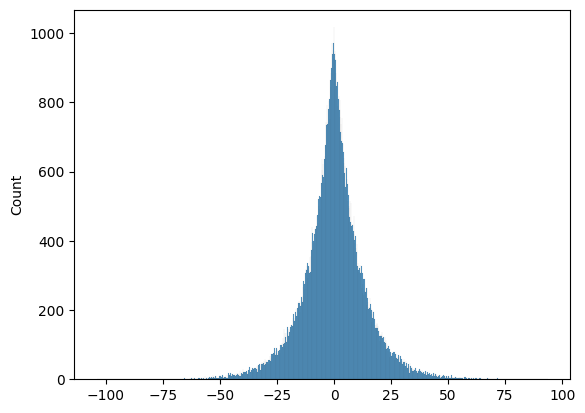

In [70]:
import seaborn as sns

#for current_b in [0.1, 1.0, 10.0]:
for current_b in [10]:
    list_of_absolute_differences = []
    list_of_differences = []
    for _ in range(100000):
        y_true = 51
        y_priv = laplace_mechanism(y_true, b=current_b)
        abs_diff = np.abs(y_priv - y_true)
        list_of_absolute_differences.append(abs_diff)
        list_of_differences.append(y_priv - y_true)

    # plot the histogram
    # sns.histplot(list_of_absolute_differences)
    sns.histplot(list_of_differences, bins=1000)


## Task 5: Danger of repeated queries

What if the curator lets you ask the same question 1,000 times?

**The Scenario:**
A curator has a secret count $y_{\textrm{true}} = 51$. Every time you ask, they give you $y_{\mathrm{true}} + \text{Lap}(b=1.0)$.

**Task:**

1. Perform a single query. Notice how much noise there is.
2. Perform the query 1,000 times and store the results in an array.
3. Calculate the cumulative mean of these 1,000 results (e.g., the mean of the first 1, the first 2, the first 10, etc.).
4. Plot or print the result. How many queries does it take before the noise "averages out" and you are within $\pm 0.1$ of the true value 51?

In [ ]:
# TODO

## Task 6: Outliers and rounding

You have a database of 100 users inclucing Alice. She is the only one who took drugs.

**Task:**

1. Run empirical simulation with a Laplace mechanism with 10,000 repeats that the privacy guarantees of Alice under counting query for drug use with $b = 2$ still holds.
2. Adjust the mechanism such that if the private output $\leq 0$, it is "rounded" to $0$, and if it's $\geq 1$, it is "rounded" to $1$. Does the privacy protection still hold?

In [ ]:
# TODO lorem ipsum